# Analisi degli esperimenti

Nessun numero in questo notebook e' scritto a mano: tutto viene da `results/experiments/experiments.csv`, prodotto da `python src/run_experiments.py` secondo la griglia dichiarata in `config.yaml`. Per aggiungere un dataset, cambiare repeats o griglia dei modelli si modifica `config.yaml` e si rilancia il runner - questo notebook si aggiorna semplicemente ri-eseguendolo.

`status` per dataset (colonna in config.yaml):
- **closed**: KIMORE ex5, gia' validato a fondo in sessioni precedenti (nessun segnale, vedi MODEL_CARD) - qui girato con lo stesso rigore di tutto il resto (repeats=20) solo per riconfermare il numero, non per riaprire il caso.
- **indicative**: UI-PRMD, segnale forte ma non validabile del tutto (nessun ID soggetto nel file pubblico, target di regressione circolare) - trattato con cautela.
- **active**: REHAB24-6, la linea di lavoro attuale, con split corretto per soggetto. Tre famiglie di feature confrontate per ogni esercizio: base (PCA traiettoria posizione), dynamics (PCA posizione+velocita'+accelerazione) e anatomical (angoli articolari con nome).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)

df = pd.read_csv("../results/experiments/experiments.csv")
print(f"{df.shape[0]} righe (dataset x modello x repeat x fold)")
meta_cols = ["dataset", "task", "n_samples", "n_features", "grouped", "status"]
print(df[meta_cols].drop_duplicates().to_string(index=False))

14024 righe (dataset x modello x repeat x fold)
                              dataset           task  n_samples  n_features  grouped status
                          rehab24_ex1 classification         88          20     True active
                kimore_ex5_regression     regression         75          37    False active
                rehab24_ex1_ungrouped classification         88          20    False active
     ui_prmd_deepsquat_classification classification        180          20    False active
                          rehab24_ex2 classification        109          20     True active
                          rehab24_ex3 classification         96          20     True active
                          rehab24_ex4 classification        116          20     True active
               rehab24_ex1_anatomical classification         88          83     True active
                 rehab24_ex1_dynamics classification         88          45     True active
                   rehab24_ex1_p

Media e std tra i fold gia' danno un'idea della variabilita', ma un intervallo di confidenza richiede piu' attenzione qui: le k x repeats stime di fold non sono estrazioni indipendenti - condividono dati di training che si sovrappongono tra un fold e l'altro (stesso problema per cui Bengio & Grandvalet 2004, JMLR, hanno dimostrato che non esiste uno stimatore non distorto della varianza della k-fold CV che ignori questa correlazione). Un bootstrap ingenuo sulle stesse stime tratta quella correlazione come se non esistesse e sottostima l'incertezza reale. Qui si usa invece la correzione di Nadeau & Bengio (2003): varianza corretta della media = varianza naive x (1/n + 1/(k-1)), con k = numero di fold esterni (letto direttamente dalla colonna `fold`, non assunto), seguita da un intervallo t di Student - lo standard per CV ripetuta, non solo una scelta piu' prudente.

In [2]:
from scipy.stats import t as t_dist

df["primary_metric"] = df["auc"].where(df["task"] == "classification", df["spearman"])

def corrected_ci(g, alpha=0.05):
    """Nadeau & Bengio (2003) corrected CI for repeated k-fold CV. Naive SEM (or a naive
    bootstrap over the same correlated estimates) uses only 1/n of the variance-of-the-mean;
    the correction adds 1/(k-1) x the naive per-fold variance to account for folds sharing
    overlapping training data (Bengio & Grandvalet 2004 proved this correlation makes the
    naive estimator - bootstrap included - systematically overconfident). k is read from the
    actual `fold` column rather than assumed, since rehab24_pooled_leave_one_exercise_out uses
    6 outer folds, everything else 5."""
    values = g["primary_metric"].dropna().values
    n = len(values)
    k_outer = g["fold"].nunique()
    if n < 2 or k_outer < 2:
        return np.nan, np.nan
    mean = values.mean()
    naive_var = values.var(ddof=1)
    corrected_var = naive_var * (1.0 / n + 1.0 / (k_outer - 1))
    se = np.sqrt(corrected_var)
    tcrit = t_dist.ppf(1 - alpha / 2, df=n - 1)
    return mean - tcrit * se, mean + tcrit * se

rows = []
for (dataset, model), g in df.groupby(["dataset", "model"]):
    lo, hi = corrected_ci(g)
    rows.append({"dataset": dataset, "model": model, "mean": g["primary_metric"].mean(),
                 "std": g["primary_metric"].std(), "ci_lo": lo, "ci_hi": hi, "n_folds": g.shape[0]})
summary = pd.DataFrame(rows).sort_values(["dataset", "mean"], ascending=[True, False])
print(summary.to_string(index=False, float_format="%.3f"))

                              dataset  model   mean   std  ci_lo  ci_hi  n_folds
                kimore_ex5_regression  ridge  0.086 0.251 -0.168  0.340      100
                kimore_ex5_regression    mlp -0.006 0.256 -0.265  0.253      100
                kimore_ex5_regression     rf -0.037 0.249 -0.289  0.214      100
                kimore_ex5_regression  dummy    NaN   NaN    NaN    NaN      100
                          rehab24_ex1 logreg  0.906 0.142  0.763  1.050      100
                          rehab24_ex1    mlp  0.704 0.219  0.483  0.926      100
                          rehab24_ex1     rf  0.582 0.316  0.262  0.902      100
                          rehab24_ex1  dummy  0.489 0.120  0.368  0.610      100
               rehab24_ex1_anatomical     rf  0.779 0.182  0.595  0.964      100
               rehab24_ex1_anatomical logreg  0.761 0.113  0.647  0.875      100
               rehab24_ex1_anatomical    mlp  0.514 0.215  0.297  0.731      100
               rehab24_ex1_a

## Grafico: metrica primaria per dataset, tutti i modelli (con IC 95% bootstrap)

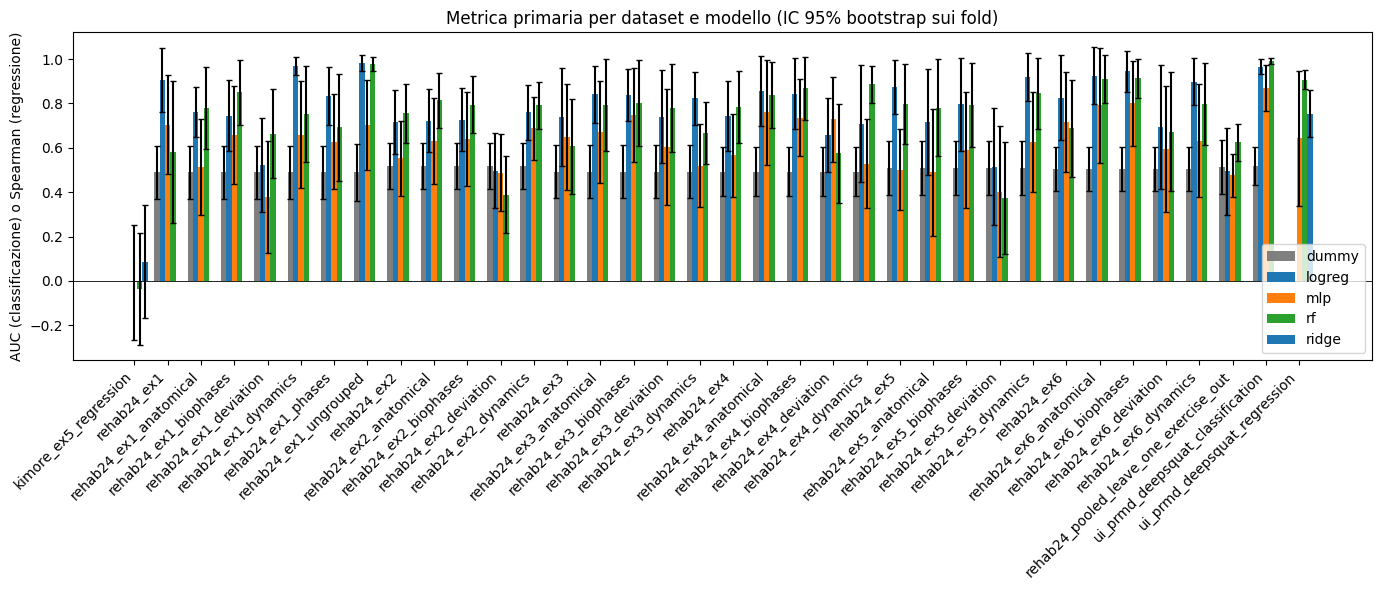

In [3]:
datasets = summary["dataset"].unique()
models = sorted(df["model"].unique())
colors = {"dummy": "tab:gray", "ridge": "tab:blue", "logreg": "tab:blue",
          "rf": "tab:green", "mlp": "tab:orange"}

fig, ax = plt.subplots(figsize=(14, 6))
width = 0.8 / len(models)
x = np.arange(len(datasets))

for i, model in enumerate(models):
    means, err_lo, err_hi = [], [], []
    for d in datasets:
        row = summary[(summary["dataset"] == d) & (summary["model"] == model)]
        if len(row):
            m, lo, hi = row["mean"].values[0], row["ci_lo"].values[0], row["ci_hi"].values[0]
        else:
            m, lo, hi = np.nan, np.nan, np.nan
        means.append(m)
        err_lo.append(m - lo if not np.isnan(m) else 0)
        err_hi.append(hi - m if not np.isnan(m) else 0)
    ax.bar(x + i * width, means, width, yerr=[err_lo, err_hi], label=model,
           color=colors.get(model, "tab:purple"), capsize=2)

ax.axhline(0, color="black", linewidth=0.6)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(datasets, rotation=45, ha="right")
ax.set_ylabel("AUC (classificazione) o Spearman (regressione)")
ax.set_title("Metrica primaria per dataset e modello (IC 95% bootstrap sui fold)")
ax.legend()
plt.tight_layout()
plt.show()

## Scelta metodologica: perche' il raggruppamento per soggetto conta

`rehab24_ex1` e `rehab24_ex1_ungrouped` usano identiche feature e identico modello: l'unica differenza e' se la nested CV rispetta i confini di soggetto (`groups: subject`) o tratta ogni ripetizione come indipendente (`groups: null`, split per riga, rischio di leakage).

              dataset  model  mean   std  ci_lo  ci_hi  n_folds
          rehab24_ex1 logreg 0.906 0.142  0.763  1.050      100
          rehab24_ex1    mlp 0.704 0.219  0.483  0.926      100
          rehab24_ex1     rf 0.582 0.316  0.262  0.902      100
          rehab24_ex1  dummy 0.489 0.120  0.368  0.610      100
rehab24_ex1_ungrouped logreg 0.981 0.035  0.946  1.017      100
rehab24_ex1_ungrouped     rf 0.978 0.033  0.945  1.012      100
rehab24_ex1_ungrouped    mlp 0.704 0.200  0.502  0.906      100
rehab24_ex1_ungrouped  dummy 0.489 0.125  0.362  0.616      100


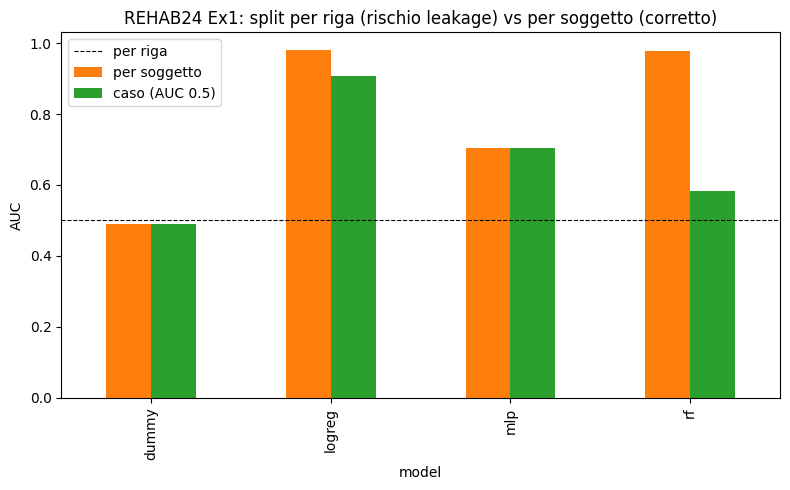

In [4]:
compare = summary[summary["dataset"].isin(["rehab24_ex1", "rehab24_ex1_ungrouped"])]
print(compare.to_string(index=False, float_format="%.3f"))

fig, ax = plt.subplots(figsize=(8, 5))
sub = compare.pivot(index="model", columns="dataset", values="mean")
sub = sub.reindex(columns=["rehab24_ex1_ungrouped", "rehab24_ex1"])
sub.plot(kind="bar", ax=ax, color=["tab:orange", "tab:green"])
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
ax.set_ylabel("AUC")
ax.set_title("REHAB24 Ex1: split per riga (rischio leakage) vs per soggetto (corretto)")
ax.legend(["per riga", "per soggetto", "caso (AUC 0.5)"])
plt.tight_layout()
plt.show()

## Su quanti esercizi REHAB24 il segnale regge?

Tutti e sei con split corretto per soggetto, stesse feature (trajectory-PCA), stessi modelli.

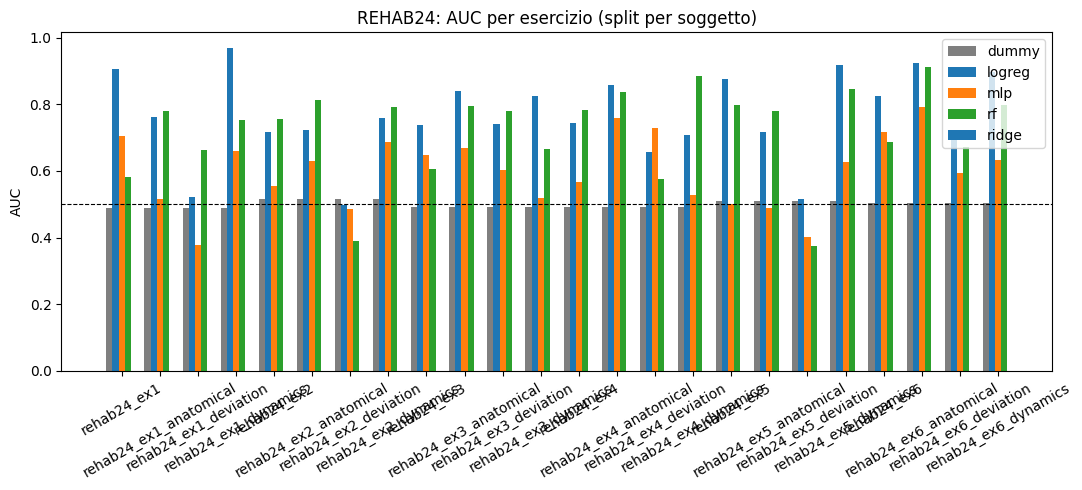

In [5]:
rehab_cols = [d for d in datasets if d.startswith("rehab24_ex") and "ungrouped" not in d and "phases" not in d]
rehab_summary = summary[summary["dataset"].isin(rehab_cols)]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(rehab_cols))
for i, model in enumerate(models):
    means = [rehab_summary[(rehab_summary["dataset"] == d) & (rehab_summary["model"] == model)]["mean"].values
             for d in rehab_cols]
    means = [m[0] if len(m) else np.nan for m in means]
    ax.bar(x + i * width, means, width, label=model, color=colors.get(model, "tab:purple"))

ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(rehab_cols, rotation=30)
ax.set_ylabel("AUC")
ax.set_title("REHAB24: AUC per esercizio (split per soggetto)")
ax.legend()
plt.tight_layout()
plt.show()

## Le fasi del movimento aiutano? (idea da Temporal Parsing Transformer / FineParser)

`rehab24_ex1_phases` divide ogni ripetizione in tre terzi temporali (inizio/meta/fine) e fa la PCA separatamente su ciascuno, invece che sull'intera traiettoria. Non e' un parser appreso come nei paper, ma la stessa intuizione tenuta semplice: l'errore potrebbe concentrarsi in una fase specifica piuttosto che nell'intero movimento.

In [6]:
compare_phases = summary[summary["dataset"].isin(["rehab24_ex1", "rehab24_ex1_phases"])]
print(compare_phases.to_string(index=False, float_format="%.3f"))
print("\nSe 'rehab24_ex1_phases' non supera 'rehab24_ex1', la segmentazione per fasi non")
print("aggiunge segnale qui, almeno in questa forma (equal-thirds).")

           dataset  model  mean   std  ci_lo  ci_hi  n_folds
       rehab24_ex1 logreg 0.906 0.142  0.763  1.050      100
       rehab24_ex1    mlp 0.704 0.219  0.483  0.926      100
       rehab24_ex1     rf 0.582 0.316  0.262  0.902      100
       rehab24_ex1  dummy 0.489 0.120  0.368  0.610      100
rehab24_ex1_phases logreg 0.833 0.130  0.701  0.965      100
rehab24_ex1_phases     rf 0.692 0.240  0.449  0.935      100
rehab24_ex1_phases    mlp 0.627 0.211  0.414  0.841      100
rehab24_ex1_phases  dummy 0.489 0.120  0.368  0.610      100

Se 'rehab24_ex1_phases' non supera 'rehab24_ex1', la segmentazione per fasi non
aggiunge segnale qui, almeno in questa forma (equal-thirds).


## Quale famiglia di feature vince, esercizio per esercizio?

base (PCA sulla sola posizione), dynamics (PCA su posizione+velocita'+accelerazione), anatomical (angoli articolari con nome), biophases (angoli suddivisi per fase descent/bottom/ascent) e deviation (deviazione media assoluta da una traiettoria di riferimento leave-subject-out) non sono alternative teoriche - ci sono 6 esercizi x 5 famiglie x modelli per dire quale vince davvero, e dove.

exercise     family best_model  mean  ci_lo  ci_hi  dummy  uplift_vs_dummy  beats_dummy_ci
     ex1       base     logreg 0.906  0.763  1.050  0.489            0.417            True
     ex1   dynamics     logreg 0.968  0.928  1.007  0.489            0.479            True
     ex1 anatomical         rf 0.779  0.595  0.964  0.489            0.290           False
     ex1  biophases         rf 0.850  0.702  0.997  0.489            0.360            True
     ex1  deviation         rf 0.664  0.464  0.863  0.489            0.174           False
     ex2       base         rf 0.756  0.622  0.889  0.517            0.239            True
     ex2   dynamics         rf 0.791  0.684  0.898  0.517            0.274            True
     ex2 anatomical         rf 0.814  0.690  0.938  0.517            0.297            True
     ex2  biophases         rf 0.794  0.665  0.923  0.517            0.278            True
     ex2  deviation     logreg 0.496  0.328  0.665  0.517           -0.020           False

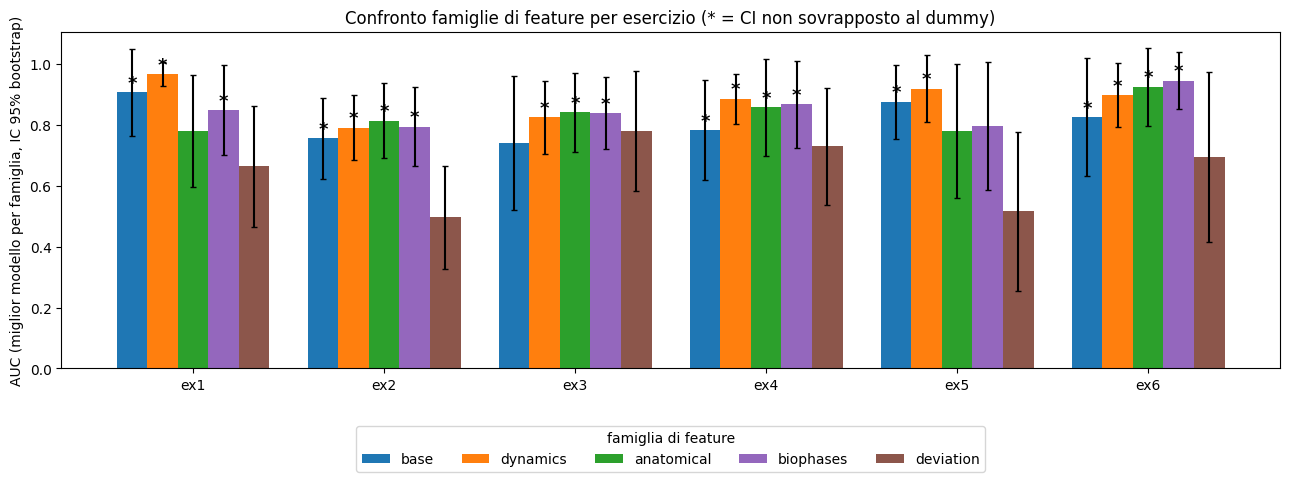

In [7]:
families = {"base": "", "dynamics": "_dynamics", "anatomical": "_anatomical",
            "biophases": "_biophases", "deviation": "_deviation"}
exercises = [f"ex{i}" for i in range(1, 7)]

best_rows = []
for ex in exercises:
    for fam, suffix in families.items():
        name = f"rehab24_{ex}{suffix}"
        sub = summary[summary["dataset"] == name]
        sub = sub[sub["model"] != "dummy"]
        if sub.empty:
            continue
        best = sub.loc[sub["mean"].idxmax()]
        dummy_row = summary[(summary["dataset"] == name) & (summary["model"] == "dummy")]
        dummy_val = dummy_row["mean"].values[0] if len(dummy_row) else np.nan
        dummy_ci_hi = dummy_row["ci_hi"].values[0] if len(dummy_row) else np.nan
        best_rows.append({"exercise": ex, "family": fam, "best_model": best["model"],
                           "mean": best["mean"], "ci_lo": best["ci_lo"], "ci_hi": best["ci_hi"],
                           "dummy": dummy_val, "uplift_vs_dummy": best["mean"] - dummy_val,
                           "beats_dummy_ci": best["ci_lo"] > dummy_ci_hi})

best_df = pd.DataFrame(best_rows)
print(best_df.to_string(index=False, float_format="%.3f"))
print("\nbeats_dummy_ci: il 95% CI bootstrap del modello migliore non si sovrappone a quello del dummy - "
      "un proxy conservativo di significativita', non un test formale.")

winner = best_df.loc[best_df.groupby("exercise")["mean"].idxmax()]
print("\nFamiglia vincente per esercizio (miglior modello, per AUC media):")
print(winner[["exercise", "family", "best_model", "mean", "beats_dummy_ci"]].to_string(index=False, float_format="%.3f"))
print(f"\nConteggio vittorie: {winner['family'].value_counts().to_dict()}")

fig, ax = plt.subplots(figsize=(13, 5))
fam_colors = {"base": "tab:blue", "dynamics": "tab:orange", "anatomical": "tab:green",
              "biophases": "tab:purple", "deviation": "tab:brown"}
x = np.arange(len(exercises))
w = 0.8 / len(families)
for i, fam in enumerate(families):
    sub = best_df[best_df["family"] == fam].set_index("exercise").reindex(exercises)
    err_lo = (sub["mean"] - sub["ci_lo"]).values
    err_hi = (sub["ci_hi"] - sub["mean"]).values
    bars = ax.bar(x + (i - (len(families) - 1) / 2) * w, sub["mean"].values, w,
                   yerr=[err_lo, err_hi], capsize=2, label=fam, color=fam_colors[fam])
    for xi, (beats, val) in enumerate(zip(sub["beats_dummy_ci"], sub["mean"])):
        if beats:
            ax.annotate("*", (x[xi] + (i - (len(families) - 1) / 2) * w, val), ha="center",
                        va="bottom", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(exercises)
ax.set_ylabel("AUC (miglior modello per famiglia, IC 95% bootstrap)")
ax.set_title("Confronto famiglie di feature per esercizio (* = CI non sovrapposto al dummy)")
ax.legend(title="famiglia di feature", ncol=len(families), loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.tight_layout()
plt.show()

## Il segnale sopravvive al cambio di esercizio?

`rehab24_pooled_leave_one_exercise_out` allena su 5 esercizi e testa sul sesto, mai visto, usando le feature anatomiche (le uniche condivise concettualmente tra esercizi diversi - un angolo di ginocchio e' lo stesso angolo in uno squat o in un affondo, una componente PCA no). Con solo 6 gruppi e split deterministico, repeats=1 e' corretto (non una scorciatoia): rifare lo split non cambierebbe nulla.

                              dataset  model  mean   std  ci_lo  ci_hi  n_folds
rehab24_pooled_leave_one_exercise_out     rf 0.626 0.053  0.542  0.709        6
rehab24_pooled_leave_one_exercise_out  dummy 0.515 0.079  0.392  0.637        6
rehab24_pooled_leave_one_exercise_out logreg 0.495 0.126  0.298  0.691        6
rehab24_pooled_leave_one_exercise_out    mlp 0.475 0.064  0.376  0.574        6


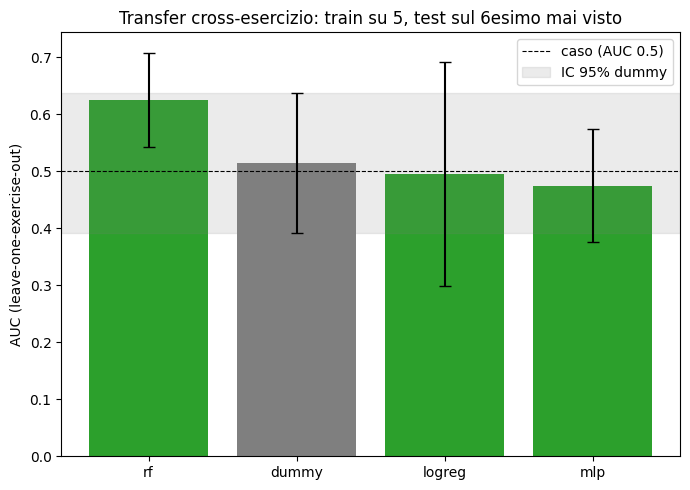


Solo il modello il cui IC 95% non si sovrappone a quello del dummy batte il caso in
modo difendibile con soli 6 fold. Con questo campione (6 esercizi), un IC largo e'
atteso: questo e' un segnale di transfer modesto, non forte - un indizio che
l'informazione utile non e' del tutto specifica per esercizio, non una
dimostrazione di transfer robusto verso un nuovo dominio.


In [8]:
loeo = summary[summary["dataset"] == "rehab24_pooled_leave_one_exercise_out"].sort_values("mean", ascending=False)
print(loeo.to_string(index=False, float_format="%.3f"))

dummy_ci = loeo[loeo["model"] == "dummy"][["ci_lo", "ci_hi"]].values[0]
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(loeo["model"], loeo["mean"],
       yerr=[loeo["mean"] - loeo["ci_lo"], loeo["ci_hi"] - loeo["mean"]],
       capsize=4, color=["tab:green" if m != "dummy" else "tab:gray" for m in loeo["model"]])
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="caso (AUC 0.5)")
ax.axhspan(dummy_ci[0], dummy_ci[1], color="tab:gray", alpha=0.15, label="IC 95% dummy")
ax.set_ylabel("AUC (leave-one-exercise-out)")
ax.set_title("Transfer cross-esercizio: train su 5, test sul 6esimo mai visto")
ax.legend()
plt.tight_layout()
plt.show()

print("\nSolo il modello il cui IC 95% non si sovrappone a quello del dummy batte il caso in")
print("modo difendibile con soli 6 fold. Con questo campione (6 esercizi), un IC largo e'")
print("atteso: questo e' un segnale di transfer modesto, non forte - un indizio che")
print("l'informazione utile non e' del tutto specifica per esercizio, non una")
print("dimostrazione di transfer robusto verso un nuovo dominio.")

## Tabella completa (tutti i dataset, tutti i modelli)

In [9]:
print(summary.to_string(index=False, float_format="%.3f"))

                              dataset  model   mean   std  ci_lo  ci_hi  n_folds
                kimore_ex5_regression  ridge  0.086 0.251 -0.168  0.340      100
                kimore_ex5_regression    mlp -0.006 0.256 -0.265  0.253      100
                kimore_ex5_regression     rf -0.037 0.249 -0.289  0.214      100
                kimore_ex5_regression  dummy    NaN   NaN    NaN    NaN      100
                          rehab24_ex1 logreg  0.906 0.142  0.763  1.050      100
                          rehab24_ex1    mlp  0.704 0.219  0.483  0.926      100
                          rehab24_ex1     rf  0.582 0.316  0.262  0.902      100
                          rehab24_ex1  dummy  0.489 0.120  0.368  0.610      100
               rehab24_ex1_anatomical     rf  0.779 0.182  0.595  0.964      100
               rehab24_ex1_anatomical logreg  0.761 0.113  0.647  0.875      100
               rehab24_ex1_anatomical    mlp  0.514 0.215  0.297  0.731      100
               rehab24_ex1_a

## Sintesi

1. **KIMORE ex5**: chiuso (nessun segnale in nessuna formulazione, 9+ strategie indipendenti provate).
2. **UI-PRMD**: indicativo, non conclusivo (nessun ID soggetto nel file pubblico rilasciato).
3. **REHAB24-6, famiglie di feature**: su 6 esercizi, `dynamics` (posizione+velocita'+accelerazione) vince 3 volte (ex1, ex4, ex5), `anatomical` 2 volte (ex2, ex3), `biophases` una volta (ex6). `deviation` (distanza dalla traiettoria di riferimento) non vince mai, nonostante l'ingegnerizzazione leakage-safe leave-subject-out - il segnale univariato per singola feature esiste (vedi notebook 06) ma non si aggrega in un vantaggio multivariato con questi campioni piccoli. `anatomical` e `biophases` restano le uniche famiglie con feature nominabili (angolo del ginocchio, valgismo, asimmetria, per fase).
4. **Transfer cross-esercizio**: segnale presente solo nella media (rf 0.626 vs dummy 0.515) ma nessun modello supera dummy in modo difendibile secondo il criterio piu' severo (IC 95% non sovrapposto) - con soli 6 fold gli IC sono ampi e si sovrappongono tutti. Un indizio di transfer, non una dimostrazione.